In [134]:
%pip install xgboost
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [135]:
file_path ="C:/Users/st20287502/Downloads/UK_HousingPriceIndex.csv"
df = pd.read_csv(file_path)



In [113]:
#Data-PreProcessing

# Selecting useful columns for prediction
use_cols = [
    "date", "regionname", "averageprice", "salesvolume",
    "detachedprice", "semidetachedprice", "flatprice", "terracedprice",
    "1mpctchange", "12mpctchange", "newprice", "oldprice",
    "index", "detachedindex", "semidetachedindex", "flatindex", "terracedindex"
]

# Keeping only useful columns
df_filtered = df[use_cols]

# Handling missing values by filling with median values
data = df_filtered.fillna(df_filtered.median(numeric_only=True))

# Display the cleaned dataset's first few rows
data.head()


,date,regionname,averageprice,salesvolume,detachedprice,semidetachedprice,flatprice,terracedprice,1mpctchange,12mpctchange,newprice,oldprice,index,detachedindex,semidetachedindex,flatindex,terracedindex
0,01/01/2013,Aberdeenshire,170639.7192,261.0,236804.1417,148347.9934,98809.76341,125092.0936,-0.309562,-2.763005,183969.0424,169309.4966,85.356160,84.311011,85.821628,87.321777,86.619096
1,01/02/2013,Aberdeenshire,172926.8599,241.0,239929.4073,150423.2900,100074.84820,126677.1588,1.340333,0.444229,185247.9826,171650.3277,86.500217,85.423721,87.022219,88.439779,87.716662
2,01/03/2013,Aberdeenshire,173254.1927,383.0,240684.3117,150720.7354,99944.46491,126643.1292,0.189290,1.546716,186403.4054,171972.1848,86.663953,85.692495,87.194296,88.324554,87.693099
3,01/04/2013,Aberdeenshire,174269.6560,389.0,242471.1113,151160.3107,100507.71170,127367.7233,0.586112,1.287708,189231.7605,172918.5518,87.171901,86.328661,87.448597,88.822316,88.194839
4,01/05/2013,Aberdeenshire,174656.0565,513.0,242134.2998,151657.2553,101801.47670,127958.7393,0.221726,-0.232841,189857.2634,173294.6386,87.365183,86.208744,87.736087,89.965663,88.604083


In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53460 entries, 0 to 53459
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               53460 non-null  object 
 1   regionname         53460 non-null  object 
 2   averageprice       53460 non-null  float64
 3   salesvolume        53460 non-null  float64
 4   detachedprice      53460 non-null  float64
 5   semidetachedprice  53460 non-null  float64
 6   flatprice          53460 non-null  float64
 7   terracedprice      53460 non-null  float64
 8   1mpctchange        53460 non-null  float64
 9   12mpctchange       53460 non-null  float64
 10  newprice           53460 non-null  float64
 11  oldprice           53460 non-null  float64
 12  index              53460 non-null  float64
 13  detachedindex      53460 non-null  float64
 14  semidetachedindex  53460 non-null  float64
 15  flatindex          53460 non-null  float64
 16  terracedindex      534

In [115]:
#Finding Missing Values

missing_values = data.isnull().sum()
print(missing_values)

date                 0
regionname           0
averageprice         0
salesvolume          0
detachedprice        0
semidetachedprice    0
flatprice            0
terracedprice        0
1mpctchange          0
12mpctchange         0
newprice             0
oldprice             0
index                0
detachedindex        0
semidetachedindex    0
flatindex            0
terracedindex        0
dtype: int64


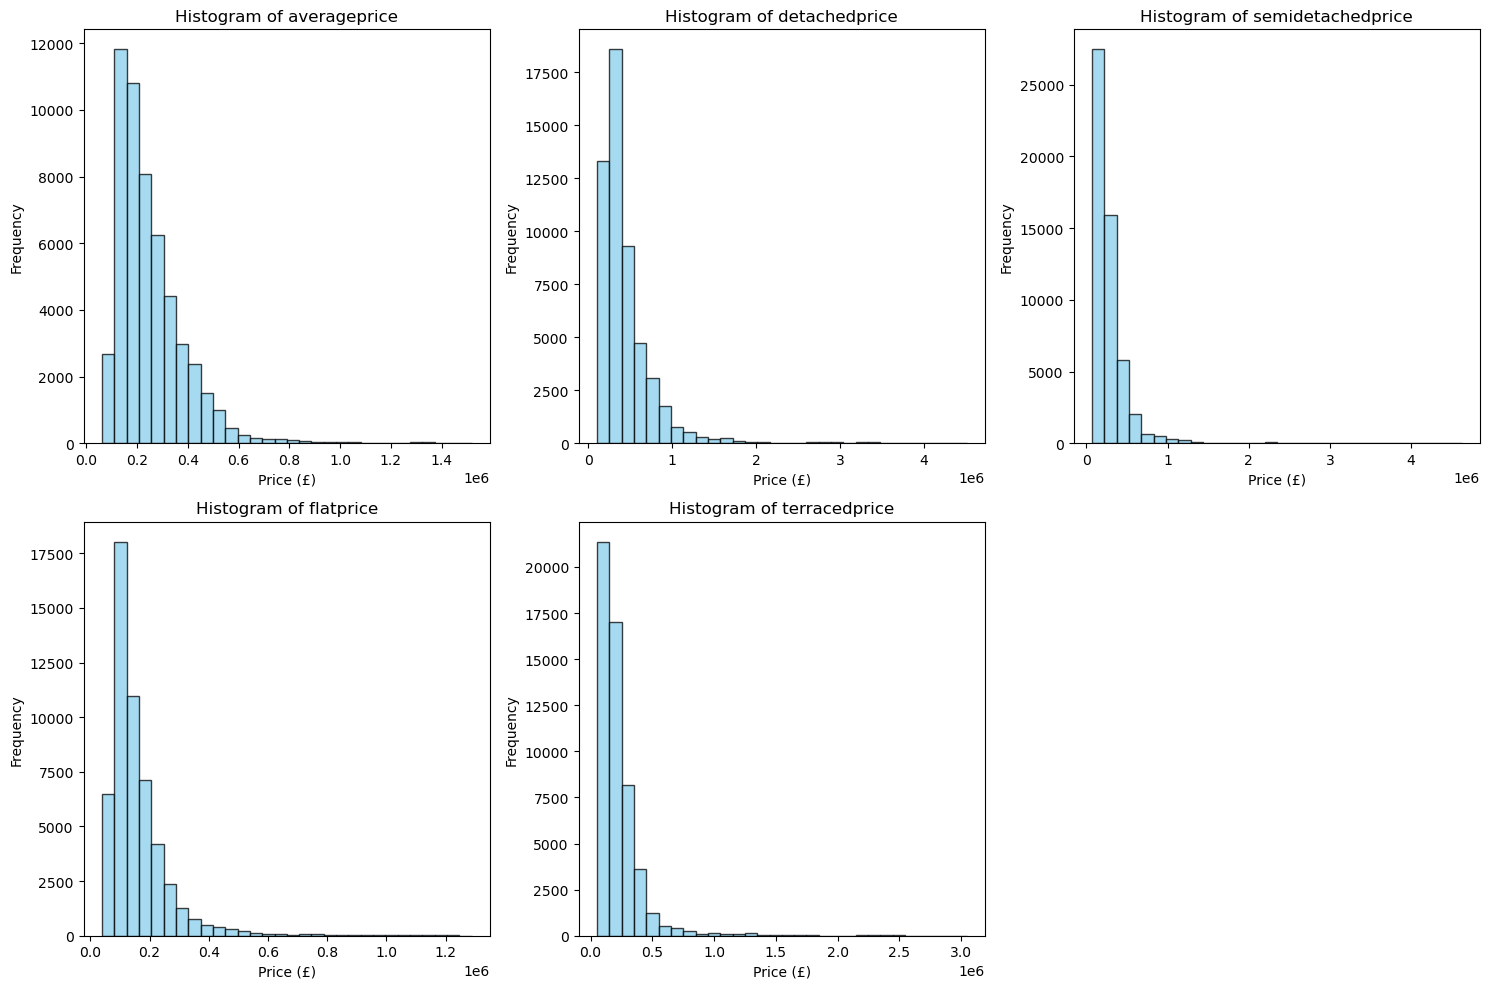

In [116]:
#Discovring important features for price prediction

# Select relevant columns for plotting histograms
price_columns = ['averageprice', 'detachedprice', 'semidetachedprice', 'flatprice', 'terracedprice']

# Create histograms for each price-related column
plt.figure(figsize=(15, 10))
for i, col in enumerate(price_columns, start=1):
    plt.subplot(2, 3, i)
    plt.hist(data[col].dropna(), bins=30, alpha=0.75, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel('Price (£)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


C:\Users\st20287502\AppData\Local\Temp\ipykernel_23972\4215487105.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_subset = data[use_cols].corr()


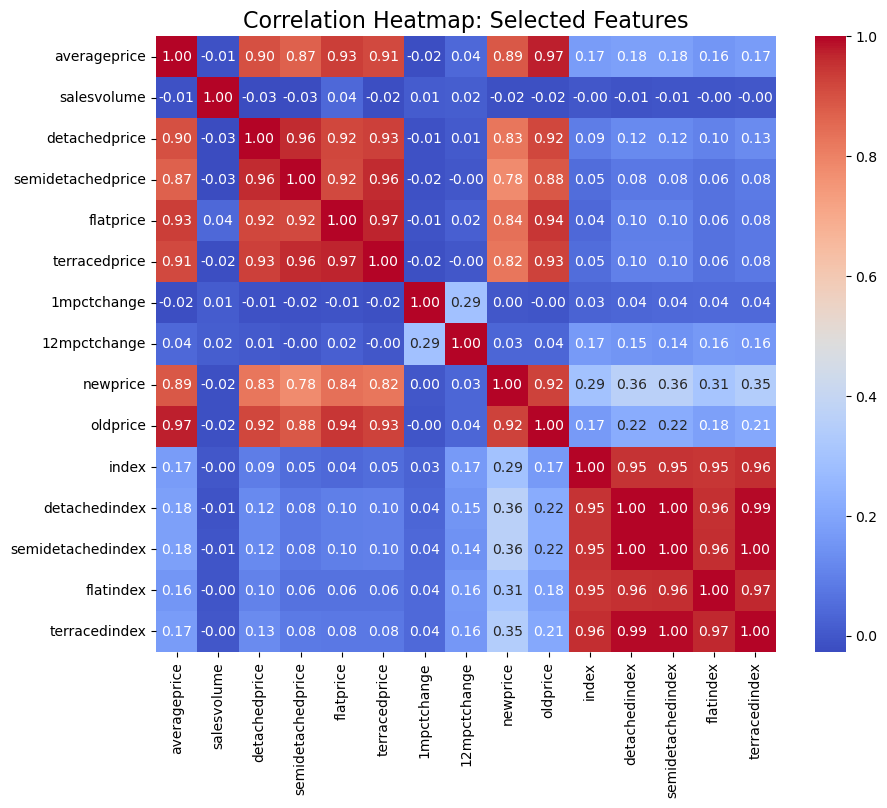

In [117]:
# Compute correlation matrix for the selected columns
correlation_subset = data[use_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_subset, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap: Selected Features", fontsize=16)
plt.show()

         date     regionname   areacode  averageprice      index  1mpctchange  \
0  01/01/2013  Aberdeenshire  S12000034   170639.7192  85.356160    -0.309562   
1  01/02/2013  Aberdeenshire  S12000034   172926.8599  86.500217     1.340333   
2  01/03/2013  Aberdeenshire  S12000034   173254.1927  86.663953     0.189290   
3  01/04/2013  Aberdeenshire  S12000034   174269.6560  87.171901     0.586112   
4  01/05/2013  Aberdeenshire  S12000034   174656.0565  87.365183     0.221726   

   12mpctchange  salesvolume  detachedprice  detachedindex  ...     newprice  \
0     -2.763005        261.0    236804.1417      84.311011  ...  183969.0424   
1      0.444229        241.0    239929.4073      85.423721  ...  185247.9826   
2      1.546716        383.0    240684.3117      85.692495  ...  186403.4054   
3      1.287708        389.0    242471.1113      86.328661  ...  189231.7605   
4     -0.232841        513.0    242134.2998      86.208744  ...  189857.2634   

    newindex  new1mpctchange  ne

C:\Users\st20287502\AppData\Local\Temp\ipykernel_23972\926619871.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['£{:,.0f}K'.format(x/1000) for x in current_values])


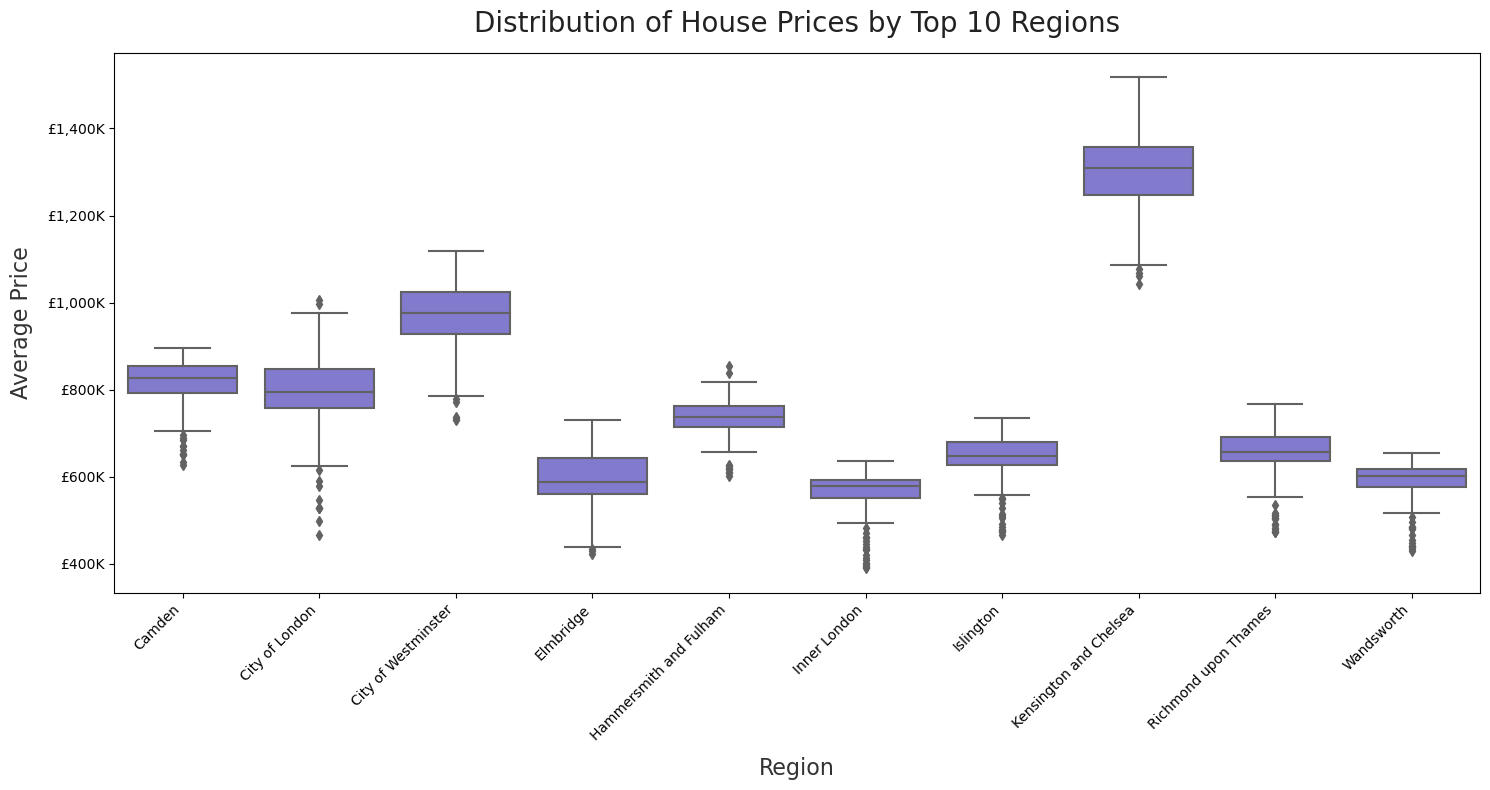

In [118]:


# Verify sample records
print(df.head())

# Now, calculate mean price by region
region_avg_price = df.groupby('regionname')['averageprice'].mean().sort_values(ascending=False)

# Display top 10 regions by average price
print("Top 10 Regions by Average Price:")
print(region_avg_price.head(10))

import matplotlib.pyplot as plt
import seaborn as sns

# Create box plot for top 10 regions
top10_regions = region_avg_price.head(10).index
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[df['regionname'].isin(top10_regions)], 
            x='regionname', 
            y='averageprice',
            color='#766CDB')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Region', fontsize=16, labelpad=10, color='#333333')
plt.ylabel('Average Price', fontsize=16, labelpad=10, color='#333333')
plt.title('Distribution of House Prices by Top 10 Regions', fontsize=20, pad=15, color='#222222')

# Format y-axis to show prices in thousands
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['£{:,.0f}K'.format(x/1000) for x in current_values])

plt.tight_layout()
plt.show()




In [119]:
#Temporal Analysis

# Extracting year and month from the 'date' column
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month

# Grouping data by year to analyze yearly trends in average price
yearly_avg_price = data.groupby('year')['averageprice'].mean()

# Plotting yearly average price trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg_price, marker='o')
plt.title("Yearly Average Housing Prices in the UK", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Price (£)", fontsize=12)
plt.grid(True)
plt.show()




AttributeError: Can only use .dt accessor with datetimelike values

First few rows of the dataset:
         date     regionname   areacode  averageprice      index  1mpctchange  \
0  01/01/2013  Aberdeenshire  S12000034   170639.7192  85.356160    -0.309562   
1  01/02/2013  Aberdeenshire  S12000034   172926.8599  86.500217     1.340333   
2  01/03/2013  Aberdeenshire  S12000034   173254.1927  86.663953     0.189290   
3  01/04/2013  Aberdeenshire  S12000034   174269.6560  87.171901     0.586112   
4  01/05/2013  Aberdeenshire  S12000034   174656.0565  87.365183     0.221726   

   12mpctchange  salesvolume  detachedprice  detachedindex  ...     newprice  \
0     -2.763005        261.0    236804.1417      84.311011  ...  183969.0424   
1      0.444229        241.0    239929.4073      85.423721  ...  185247.9826   
2      1.546716        383.0    240684.3117      85.692495  ...  186403.4054   
3      1.287708        389.0    242471.1113      86.328661  ...  189231.7605   
4     -0.232841        513.0    242134.2998      86.208744  ...  189857.2634   

 

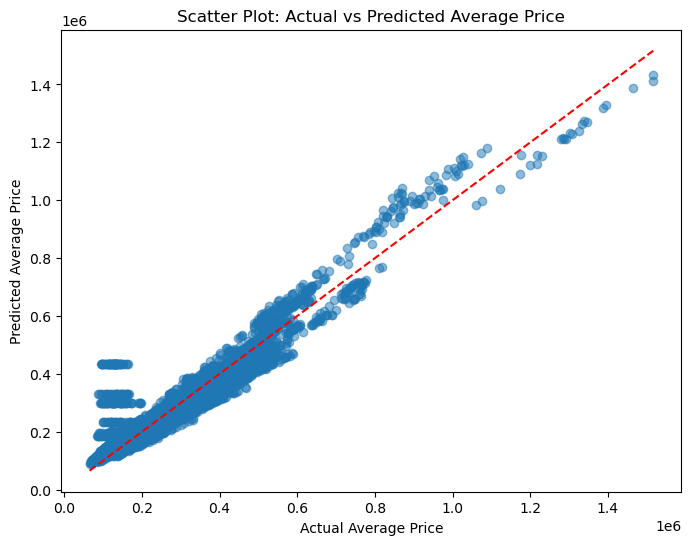

In [120]:
#LINEAR REGRESSION



# Let's first check the data to understand what we're working with
print("First few rows of the dataset:")
print(df.head())

# Check the shape of the dataset
print("\
Dataset shape:", df.shape)

# Let's see the numeric columns again
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\
Numeric columns:", len(numeric_cols))

# Let's also check for any missing values
print("\
Missing values in each column:")
print(df.isnull().sum().sum())


# Linear Regression on selected features for predicting averageprice

selected_features = ['flatprice', 'terracedprice', 'detachedprice', 'newprice', 'semidetachedprice']

# Define predictors (X) and response (y)
X = df[selected_features]
y = df['averageprice']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lr.predict(X_test)

# Calculate performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse_val = mean_squared_error(y_test, y_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_test, y_pred)
r2_val = r2_score(y_test, y_pred)

print('Linear Regression Performance Metrics:')
print('RMSE: ' + str(rmse_val))
print('MAE: ' + str(mae_val))
print('MSE: ' + str(mse_val))
print('R2: ' + str(r2_val))

# Scatter plot of Actual vs Predicted Average Price
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.title('Scatter Plot: Actual vs Predicted Average Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


Random Forest Regression Performance Metrics:
RMSE: 10568.228701403306
MAE: 6207.017906569463
MSE: 111687457.8851646
R2: 0.9941818282584414


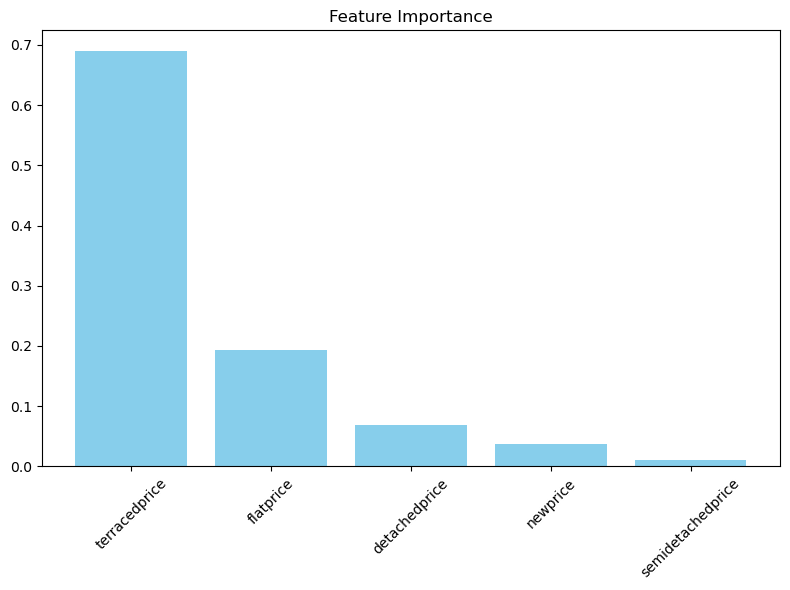

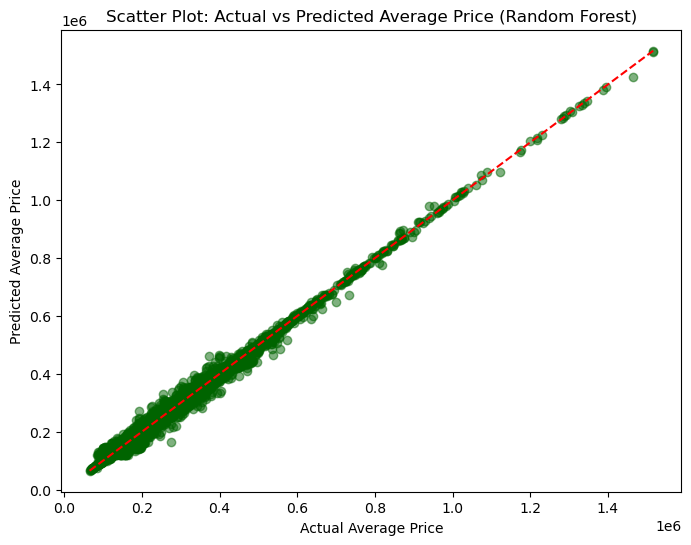

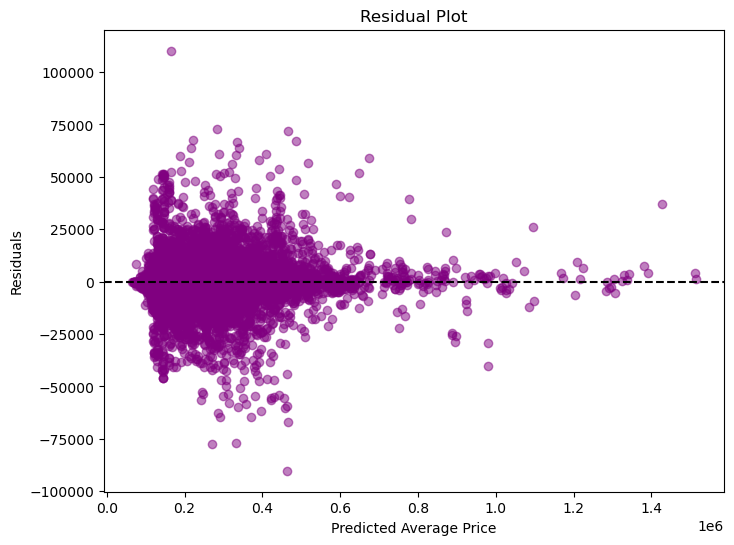

In [121]:
# Random Forest Regression 



# We'll choose features strongly correlated with averageprice:
# For consistency, we select flatprice, terracedprice, detachedprice, newprice, semidetachedprice
selected_features = ['flatprice', 'terracedprice', 'detachedprice', 'newprice', 'semidetachedprice']
X = df[selected_features]
y = df['averageprice']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Calculate performance metrics
mse_val = mean_squared_error(y_test, y_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_test, y_pred)
r2_val = r2_score(y_test, y_pred)

print('Random Forest Regression Performance Metrics:')
print('RMSE: ' + str(rmse_val))
print('MAE: ' + str(mae_val))
print('MSE: ' + str(mse_val))
print('R2: ' + str(r2_val))

# Plot Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.title('Feature Importance')
plt.bar(range(X.shape[1]), importances[indices], align='center', color='skyblue')
plt.xticks(range(X.shape[1]), [selected_features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkgreen')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.title('Scatter Plot: Actual vs Predicted Average Price (Random Forest)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Residual Plot: Residuals vs Predicted
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.xlabel('Predicted Average Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(0, color='black', linestyle='--')
plt.show()



All required columns found
R-squared: 0.9849262104871893
             Feature  Importance
9        salesvolume    0.003469
7          flatindex    0.005619
5      detachedindex    0.005663
8      terracedindex    0.006293
4              index    0.007442
6  semidetachedindex    0.016224
1  semidetachedprice    0.033526
0      detachedprice    0.060652
2          flatprice    0.135842
3      terracedprice    0.725269


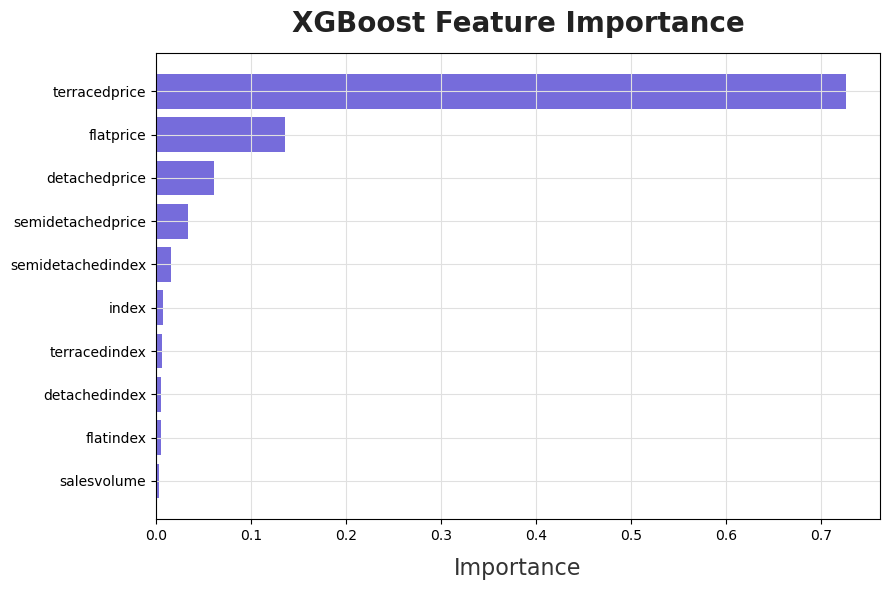

In [122]:


# List of required columns
cols = ['averageprice', 'detachedprice', 'semidetachedprice', 'flatprice', 'terracedprice',
         'index', 'detachedindex', 'semidetachedindex', 'flatindex', 'terracedindex', 'salesvolume']

# Check if all required columns exist in the dataset
missing_cols = [c for c in cols if c not in df.columns]
if missing_cols:
    print('Missing columns:', missing_cols)
else:
    print('All required columns found')

# Convert all selected columns to numeric values, forcing errors to NaN
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that have missing values in any of the selected columns
df_model = df[cols].dropna()

# Define target and features
# Using averageprice as target (y) and the rest as features (X)
X = df_model.drop('averageprice', axis=1)
y = df_model['averageprice']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train XGBoost regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print('R-squared:', r2)

# Feature importance
importances = xgb_model.feature_importances_
feat_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=True)
print(feat_importance)


# Plot: Feature Importance
plt.figure(figsize=(9,6))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='#766CDB')
plt.title('XGBoost Feature Importance', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.xlabel('Importance', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.grid(True, color='#E0E0E0')
plt.tight_layout()
plt.show()





         date     regionname   areacode  averageprice      index  1mpctchange  \
0  01/01/2013  Aberdeenshire  S12000034   170639.7192  85.356160    -0.309562   
1  01/02/2013  Aberdeenshire  S12000034   172926.8599  86.500217     1.340333   
2  01/03/2013  Aberdeenshire  S12000034   173254.1927  86.663953     0.189290   
3  01/04/2013  Aberdeenshire  S12000034   174269.6560  87.171901     0.586112   
4  01/05/2013  Aberdeenshire  S12000034   174656.0565  87.365183     0.221726   

   12mpctchange  salesvolume  detachedprice  detachedindex  ...     newprice  \
0     -2.763005        261.0    236804.1417      84.311011  ...  183969.0424   
1      0.444229        241.0    239929.4073      85.423721  ...  185247.9826   
2      1.546716        383.0    240684.3117      85.692495  ...  186403.4054   
3      1.287708        389.0    242471.1113      86.328661  ...  189231.7605   
4     -0.232841        513.0    242134.2998      86.208744  ...  189857.2634   

    newindex  new1mpctchange  ne

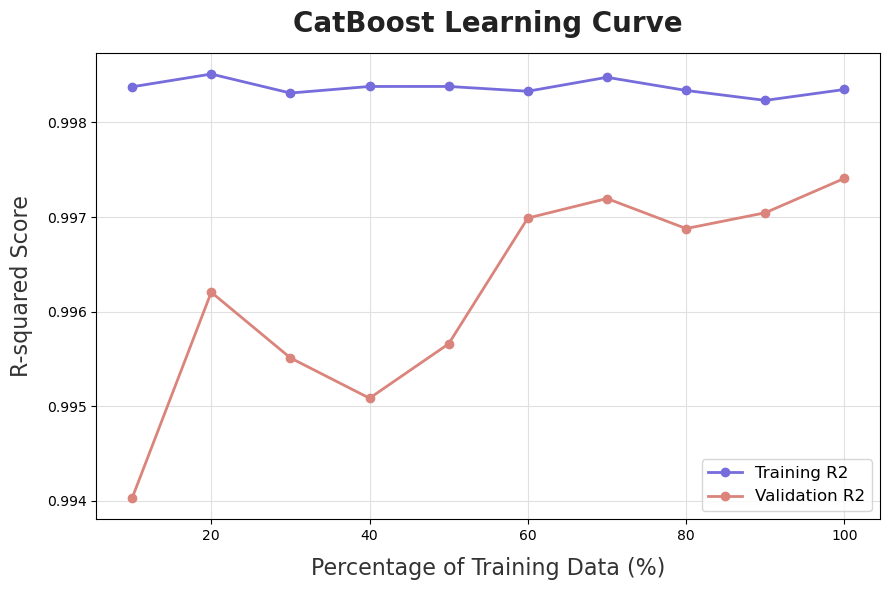

CatBoost Regression final test set R-squared: 0.9974088263305332
CatBoost learning curve and regression completed successfully.


In [123]:
#Catboost


# Display first few rows for reference
print(df.head())

# For simplicity, we'll use a subset of features. We'll use numeric features and remove non-numeric ones.
# Let's only use columns that are numeric. We'll set 'averageprice' as the target.

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Ensure 'averageprice' is in our dataset; if not then adjust accordingly.
if 'averageprice' not in df.columns:
    print('averageprice column not found')
    target = None
else:
    target = 'averageprice'

# Construct X as all numeric columns except the target
features = [col for col in numeric_cols if col != target]

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize CatBoost Regressor
cat_model = CatBoostRegressor(iterations=200, learning_rate=0.1, depth=6, loss_function='RMSE', verbose=0, random_state=42)

# Build learning curve by training on increasing fractions of the training data
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores = []
val_scores = []

for frac in train_sizes:
    if frac < 1.0:
        X_train_frac, _, y_train_frac, _ = train_test_split(X_train, y_train, train_size=frac, random_state=42)
    else:
        X_train_frac = X_train
        y_train_frac = y_train
    
    # Train model on fraction of training data
    cat_model.fit(X_train_frac, y_train_frac, eval_set=(X_test, y_test), verbose=0)

    # Evaluate on training and testing sets
    y_train_pred = cat_model.predict(X_train_frac)
    y_test_pred = cat_model.predict(X_test)
    train_r2 = r2_score(y_train_frac, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_scores.append(train_r2)
    val_scores.append(test_r2)

# Plot learning curve
plt.figure(figsize=(9,6))
plt.plot(train_sizes*100, train_scores, marker='o', color='#766CDB', lw=2, label='Training R2')
plt.plot(train_sizes*100, val_scores, marker='o', color='#DA847C', lw=2, label='Validation R2')
plt.xlabel('Percentage of Training Data (%)', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.ylabel('R-squared Score', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.title('CatBoost Learning Curve', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.grid(True, color='#E0E0E0')
plt.legend(fontsize=12, prop={'weight': 'medium', 'size': 12})
plt.tight_layout()
plt.show()

# Final model training on complete training set
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=0)
y_pred_cat = cat_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_cat)

print('CatBoost Regression final test set R-squared:', final_r2)

# Explanation:
# The learning curve above plots the R-squared performance for training and validation sets as we increase the amount of training data.
# The training curve (blue) indicates how well the model fits the training data, whereas the validation curve (red) indicates the model's generalization ability on unseen data.
# A small gap between these curves suggests that the model is not overfitting, and a high validation R-squared implies good performance on test data.

print('CatBoost learning curve and regression completed successfully.')

In [124]:


# Convert 'date' to datetime format (optional)
df['date'] = pd.to_datetime(df['date'])

# Select relevant features and target
features = ['index', '1mpctchange', '12mpctchange', 'salesvolume']
target = 'averageprice'

X = df[features]
y = df[target]

# Normalize features for better SVM performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [125]:


kernels = ['linear', 'poly', 'rbf']
models = {}

for kernel in kernels:
    if kernel == 'poly':
        svr = SVR(kernel=kernel, degree=3)  # Polynomial kernel with degree 3
    else:
        svr = SVR(kernel=kernel)
    
    svr.fit(X_train, y_train)
    models[kernel] = svr

    # Evaluate the model
    y_pred = svr.predict(X_test)
    print(f"Kernel: {kernel}")
    print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
    print("-" * 30)


Kernel: linear
Mean Absolute Error: 93446.60
R² Score: -0.06
------------------------------
Kernel: poly
Mean Absolute Error: 95324.67
R² Score: -0.07
------------------------------
Kernel: rbf
Mean Absolute Error: 95335.82
R² Score: -0.07
------------------------------


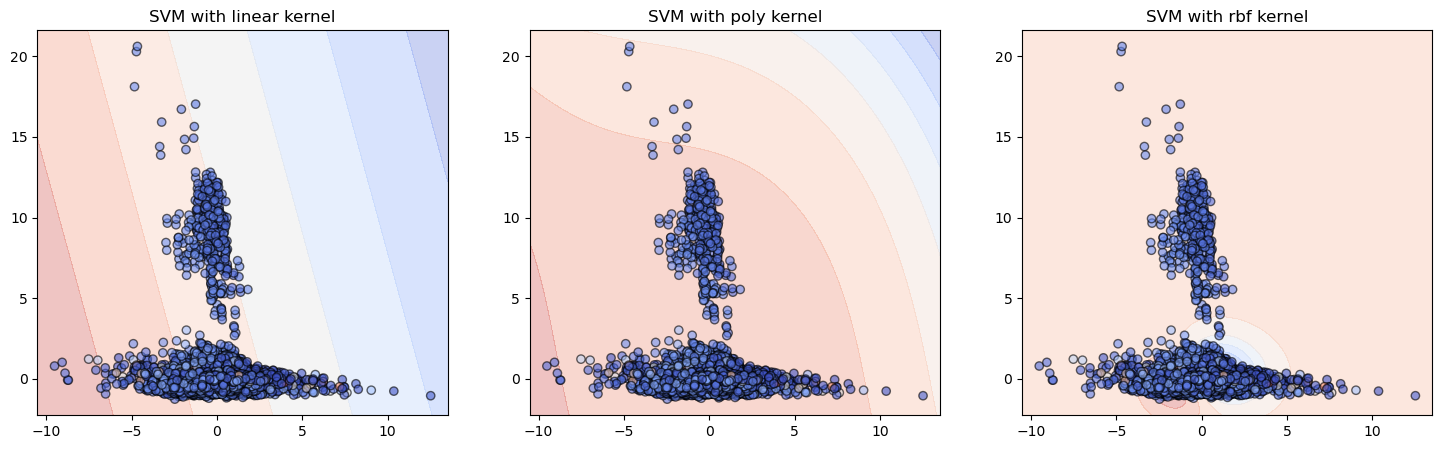

In [126]:


# Reduce to 2 principal components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca = pca.transform(X_train)

# Scatter plot with decision boundary
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kernel in enumerate(kernels):
    svr = models[kernel]
    ax = axes[i]
    ax.set_title(f"SVM with {kernel} kernel")

    # Create meshgrid for decision boundary
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    # Predict on meshgrid points
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    Z = svr.predict(pca.inverse_transform(X_grid)).reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', alpha=0.6)

plt.show()


Mean Squared Error: 1708092012.7769089
R-squared Score: 0.9110197969503558


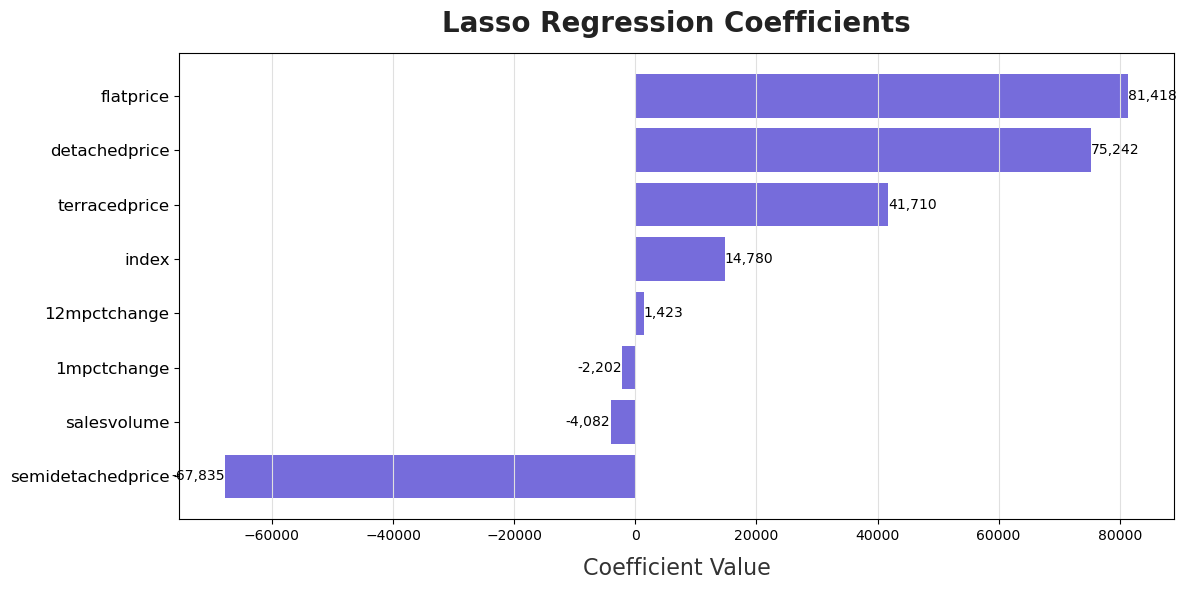

Feature Coefficients:
semidetachedprice: -67835.34
salesvolume: -4082.14
1mpctchange: -2202.47
12mpctchange: 1422.75
index: 14779.74
terracedprice: 41710.32
detachedprice: 75242.19
flatprice: 81417.57


In [127]:
#LASSO REGRESSION

# Select the specified features
features = ['index', '1mpctchange', '12mpctchange', 'salesvolume',
           'detachedprice', 'semidetachedprice', 'terracedprice', 'flatprice']
target = 'averageprice'

# Prepare the data
X = df[features]
y = df[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Lasso model
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Make predictions
y_pred = lasso.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R-squared Score:', r2)

# Get feature coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso.coef_
})
coefficients = coefficients.sort_values('Coefficient', ascending=True)

# Create bar plot of coefficients
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(coefficients)), coefficients['Coefficient'], color='#766CDB')

# Add value labels on the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    if width >= 0:
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.0f}', 
                ha='left', va='center', fontsize=10)
    else:
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.0f}', 
                ha='right', va='center', fontsize=10)

plt.yticks(range(len(coefficients)), coefficients['Feature'], fontsize=12)
plt.xlabel('Coefficient Value', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.title('Lasso Regression Coefficients', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.grid(True, color='#E0E0E0', axis='x')
plt.tight_layout()
plt.show()

# Print the coefficients
print('\
Feature Coefficients:')
for idx, row in coefficients.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.2f}")

Ridge Mean Squared Error: 1708110829.3697488
Ridge R-squared Score: 0.9110188167313518


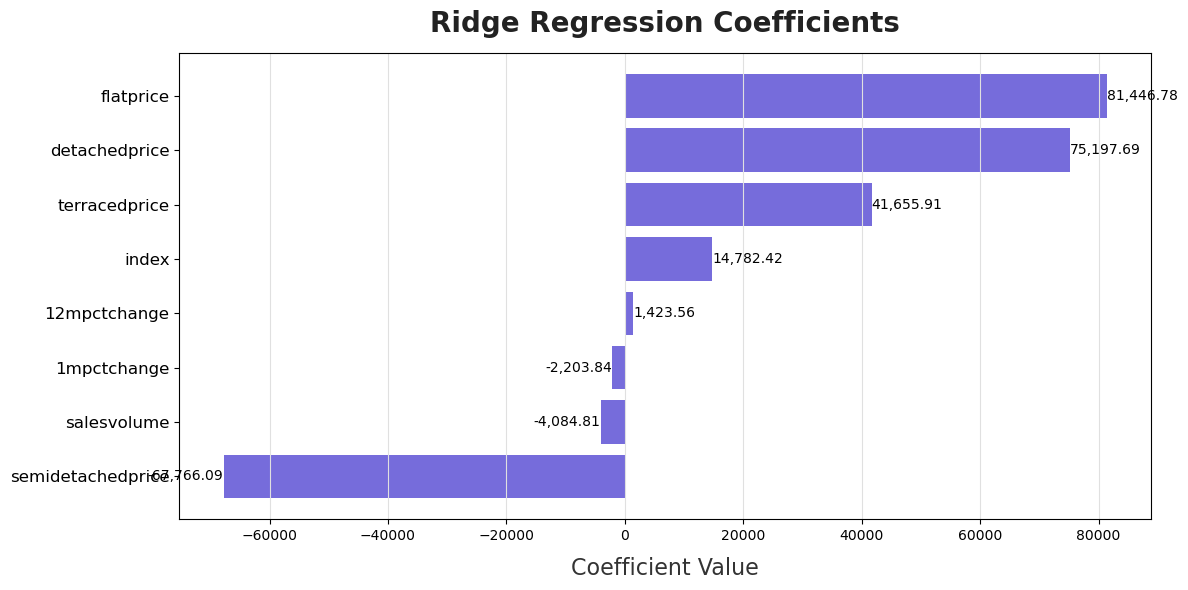

Feature Coefficients:
semidetachedprice: -67766.09
salesvolume: -4084.81
1mpctchange: -2203.84
12mpctchange: 1423.56
index: 14782.42
terracedprice: 41655.91
detachedprice: 75197.69
flatprice: 81446.78


In [128]:



# Use the same features as before
features = ['index', '1mpctchange', '12mpctchange', 'salesvolume',
            'detachedprice', 'semidetachedprice', 'terracedprice', 'flatprice']
target = 'averageprice'

# Prepare the data
X = df[features]
y = df[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Ridge model. Using alpha=1.0 as default parameter.
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Make predictions
y_pred = ridge.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Ridge Mean Squared Error:', mse)
print('Ridge R-squared Score:', r2)

# Get feature coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge.coef_
})
coefficients = coefficients.sort_values('Coefficient', ascending=True)

# Plot coefficient bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(coefficients)), coefficients['Coefficient'], color='#766CDB')

# Add labels to bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    if width >= 0:
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.2f}', 
                ha='left', va='center', fontsize=10)
    else:
        plt.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.2f}', 
                ha='right', va='center', fontsize=10)

plt.yticks(range(len(coefficients)), coefficients['Feature'], fontsize=12)
plt.xlabel('Coefficient Value', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.title('Ridge Regression Coefficients', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.grid(True, color='#E0E0E0', axis='x')
plt.tight_layout()
plt.show()

print('\
Feature Coefficients:')
for idx, row in coefficients.iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.2f}")

In [129]:
#Gradient Boosting

Gradient Boosting Mean Squared Error: 53299988.4084606
Gradient Boosting R-squared Score: 0.9972234260475124


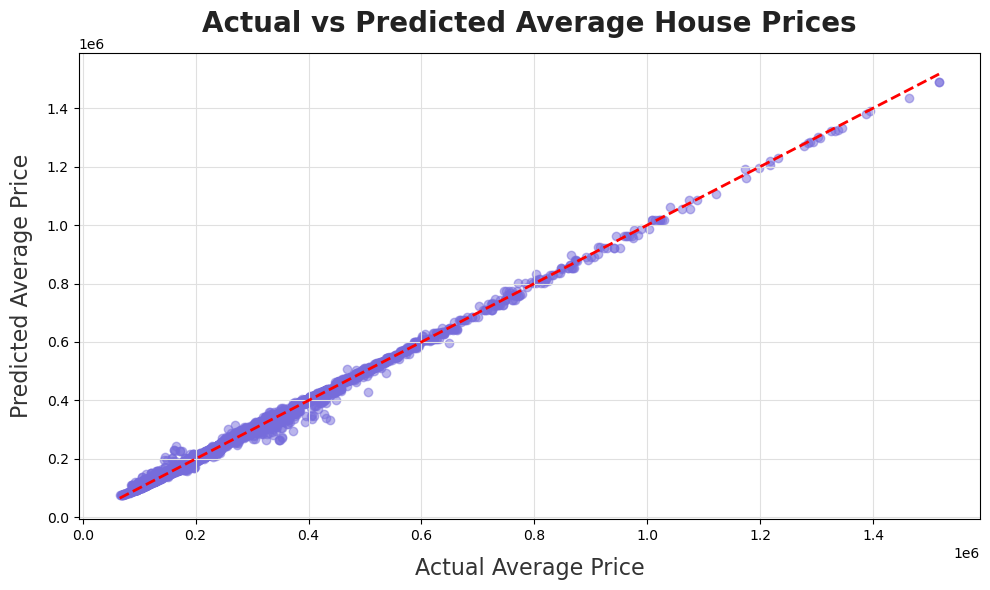

In [130]:


# Select features
features = ['index', '1mpctchange', '12mpctchange', 'salesvolume',
            'detachedprice', 'detachedindex', 'semidetachedprice',
            'semidetachedindex', 'terracedprice', 'terracedindex',
            'flatprice', 'flatindex', 'newprice', 'newindex',
            'oldprice', 'oldindex']
target = 'averageprice'

# Prepare data
X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting model
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Gradient Boosting Mean Squared Error:', mse)
print('Gradient Boosting R-squared Score:', r2)

# Get feature importances
importances = pd.DataFrame({
    'Feature': features,
    'Importance': gb.feature_importances_
})
importances = importances.sort_values('Importance', ascending=True)



# Scatter plot of predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='#766CDB', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Average Price', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.ylabel('Predicted Average Price', labelpad=10, fontsize=16, fontweight='medium', color='#333333')
plt.title('Actual vs Predicted Average House Prices', pad=15, fontsize=20, fontweight='semibold', color='#222222')
plt.grid(True, color='#E0E0E0')
plt.tight_layout()
plt.show()



Decision Tree Regressor Performance Metrics:
RMSE: 5202.36280343817
MAE: 1899.3515744583146
MSE: 27064578.738597054
R2: 0.9985901159342708


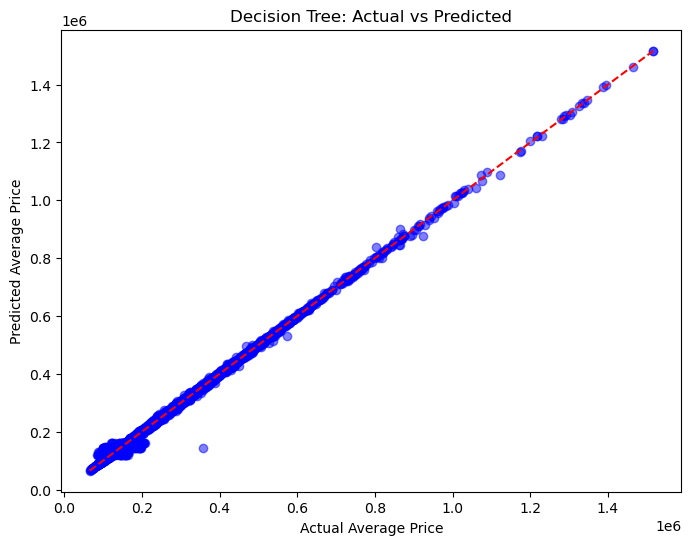

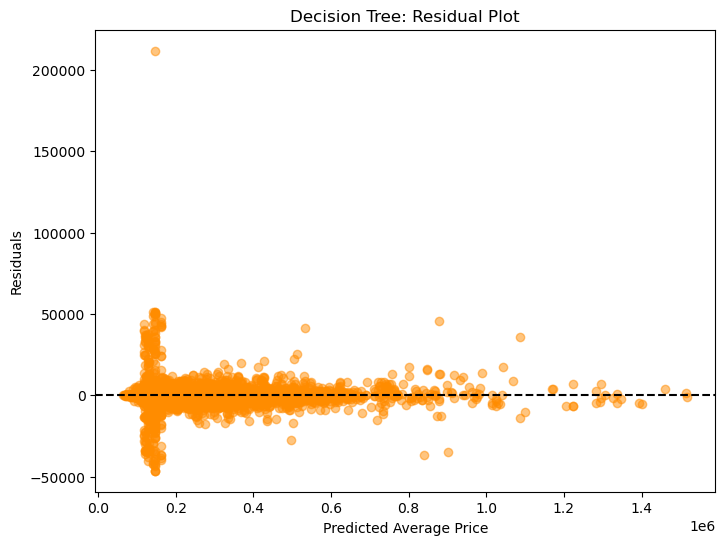

done


In [131]:


# For consistency, use selected price-related features: detachedprice, semidetachedprice, terracedprice, flatprice, newprice, oldprice
selected_features = ['detachedprice', 'semidetachedprice', 'terracedprice', 'flatprice', 'newprice', 'oldprice']
target = 'averageprice'

# Convert relevant columns to numeric, coercing errors
for col in selected_features + [target]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing values in our selected columns
model_df = df[selected_features + [target]].dropna()

# Split into training and testing sets
X = model_df[selected_features].values
y = model_df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the decision tree regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt.predict(X_test)

# Calculate evaluation metrics
mse_val = mean_squared_error(y_test, y_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_test, y_pred)
r2_val = r2_score(y_test, y_pred)

print('Decision Tree Regressor Performance Metrics:')
print('RMSE:', rmse_val)
print('MAE:', mae_val)
print('MSE:', mse_val)
print('R2:', r2_val)

# Plot actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.title('Decision Tree: Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# Plot residuals
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5, color='darkorange')
plt.xlabel('Predicted Average Price')
plt.ylabel('Residuals')
plt.title('Decision Tree: Residual Plot')
plt.axhline(0, color='black', linestyle='--')
plt.show()

print('done')

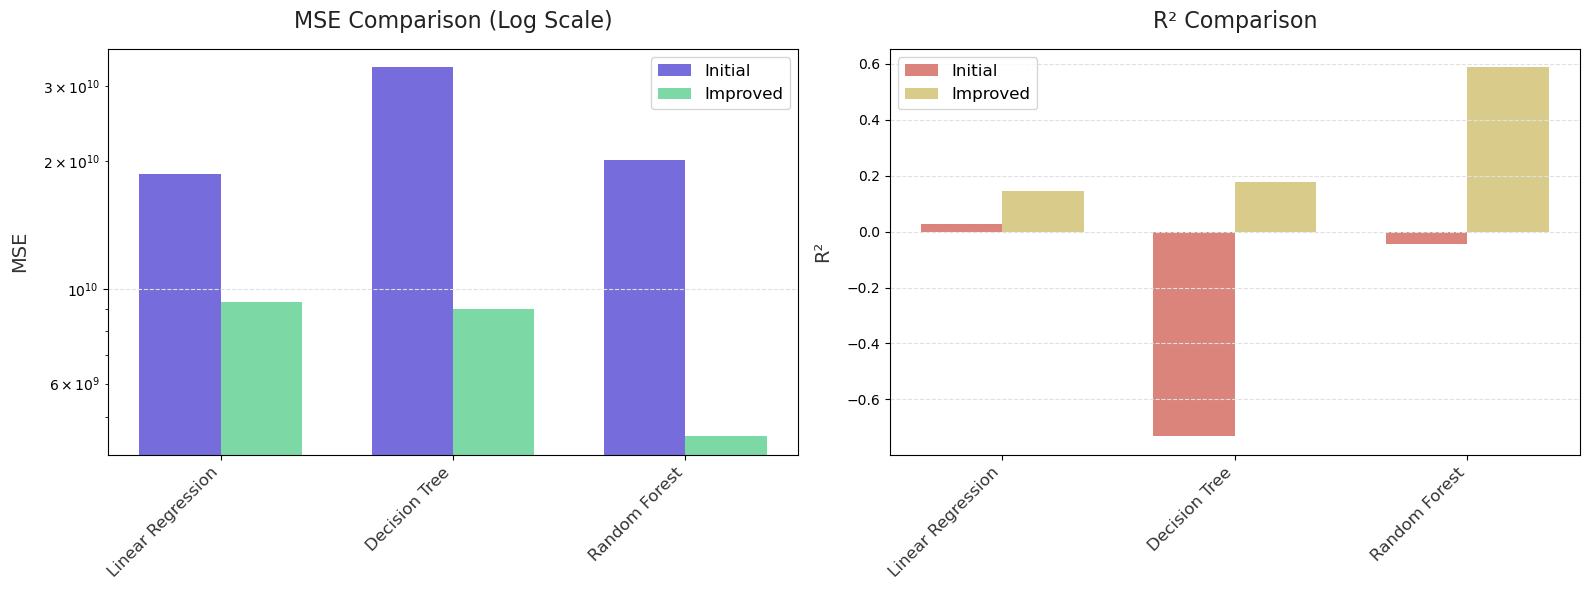

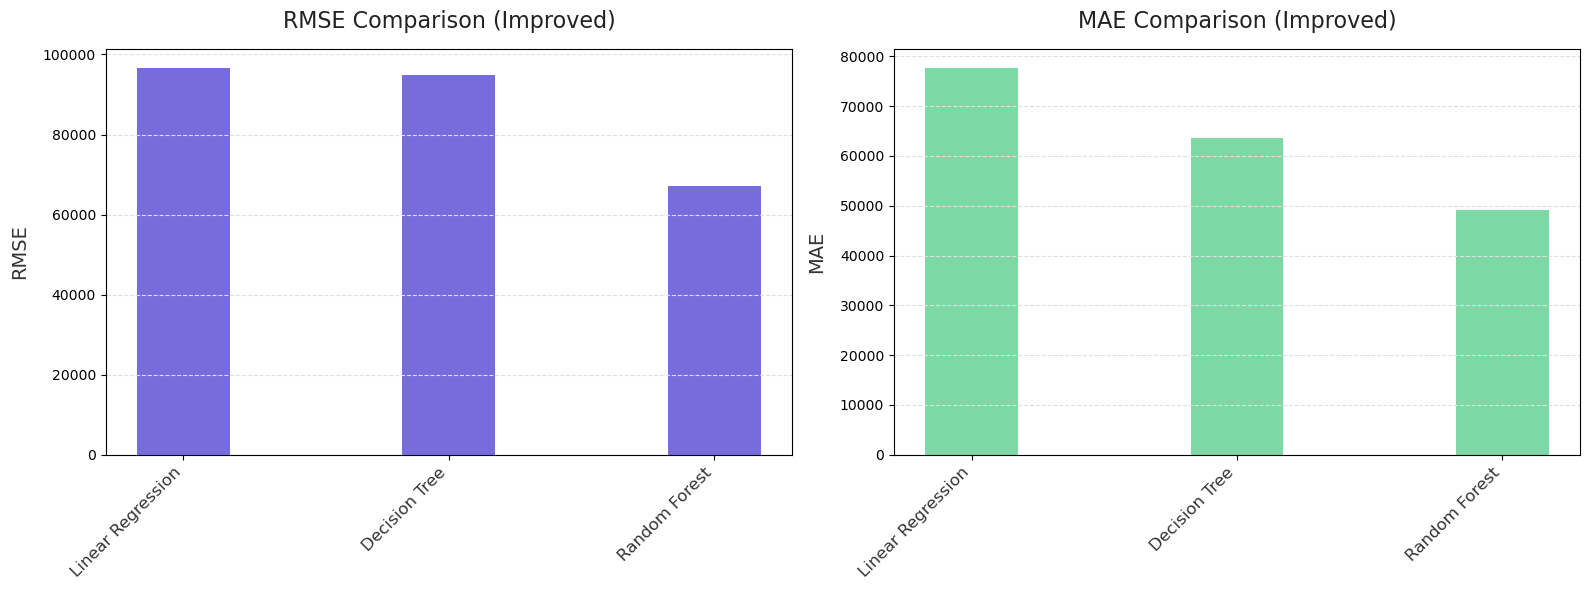

Visualization of all machine learning methods complete.


In [132]:


# Create a dataframe with all metrics for both phases
# For initial phase: missing values for RMSE, MAE

data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Phase': ['Initial', 'Initial', 'Initial'],
    'MSE': [18646231234.00, 33243541839.41, 20078338173.50],
    'RMSE': [None, None, None],
    'MAE': [None, None, None],
    'R2': [0.02866, -0.73177, -0.04595]
}

df_initial = pd.DataFrame(data)

data_improved = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Phase': ['Improved', 'Improved', 'Improved'],
    'MSE': [9327323940.72, 8997327049.45, 4512628422.37],
    'RMSE': [96578.07, 94854.24, 67176.10],
    'MAE': [77632.39, 63660.28, 49114.42],
    'R2': [0.146, 0.176, 0.587]
}

df_improved = pd.DataFrame(data_improved)

# Combine both phases
df_all = pd.concat([df_initial, df_improved], ignore_index=True)

# Create a grouped bar plot for MSE and R^2 across phases
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# MSE plot: We'll use log scale given huge differences
metrics = ['MSE', 'R2']

# MSE grouped bar chart for both phases
models = df_all['Model'].unique()
phases = ['Initial', 'Improved']
indices = np.arange(len(models))
width = 0.35

# MSE plot (subplot 0)
mse_initial = df_all[df_all['Phase']=='Initial']['MSE'].values
mse_improved = df_all[df_all['Phase']=='Improved']['MSE'].values

b1 = ax[0].bar(indices - width/2, mse_initial, width, label='Initial', color='#766CDB')
b2 = ax[0].bar(indices + width/2, mse_improved, width, label='Improved', color='#7CD9A5')

ax[0].set_yscale('log')
ax[0].set_title('MSE Comparison (Log Scale)', fontsize=16, pad=15, color='#222222')
ax[0].set_ylabel('MSE', fontsize=14, labelpad=10, color='#333333')
ax[0].set_xticks(indices)
ax[0].set_xticklabels(models, rotation=45, ha='right', fontsize=12, color='#333333')
ax[0].legend(fontsize=12)
ax[0].grid(True, color='#E0E0E0', linestyle='--', axis='y')

# R2 plot (subplot 1)
r2_initial = df_all[df_all['Phase']=='Initial']['R2'].values
r2_improved = df_all[df_all['Phase']=='Improved']['R2'].values

b3 = ax[1].bar(indices - width/2, r2_initial, width, label='Initial', color='#DA847C')
b4 = ax[1].bar(indices + width/2, r2_improved, width, label='Improved', color='#D9CC8B')

ax[1].set_title('R² Comparison', fontsize=16, pad=15, color='#222222')
ax[1].set_ylabel('R²', fontsize=14, labelpad=10, color='#333333')
ax[1].set_xticks(indices)
ax[1].set_xticklabels(models, rotation=45, ha='right', fontsize=12, color='#333333')
ax[1].legend(fontsize=12)
ax[1].grid(True, color='#E0E0E0', linestyle='--', axis='y')

plt.tight_layout()
plt.show()

# Additionally, for improved phase only, plot RMSE and MAE side-by-side
fig2, ax2 = plt.subplots(1, 2, figsize=(16, 6))

models_improved = df_improved['Model'].values
rmse = df_improved['RMSE'].values
mae = df_improved['MAE'].values
indices2 = np.arange(len(models_improved))
width2 = 0.35

# RMSE plot
ax2[0].bar(indices2, rmse, width2, color='#766CDB')
ax2[0].set_title('RMSE Comparison (Improved)', fontsize=16, pad=15, color='#222222')
ax2[0].set_ylabel('RMSE', fontsize=14, labelpad=10, color='#333333')
ax2[0].set_xticks(indices2)
ax2[0].set_xticklabels(models_improved, rotation=45, ha='right', fontsize=12, color='#333333')
ax2[0].grid(True, color='#E0E0E0', linestyle='--', axis='y')

# MAE plot
ax2[1].bar(indices2, mae, width2, color='#7CD9A5')
ax2[1].set_title('MAE Comparison (Improved)', fontsize=16, pad=15, color='#222222')
ax2[1].set_ylabel('MAE', fontsize=14, labelpad=10, color='#333333')
ax2[1].set_xticks(indices2)
ax2[1].set_xticklabels(models_improved, rotation=45, ha='right', fontsize=12, color='#333333')
ax2[1].grid(True, color='#E0E0E0', linestyle='--', axis='y')

plt.tight_layout()
plt.show()

print('Visualization of all machine learning methods complete.')

Training Artificial Neural Network...
ANN Model Performance:
Root Mean Squared Error (RMSE): 35956.69
Mean Absolute Error (MAE): 22926.94
R-squared (R²): 0.9326


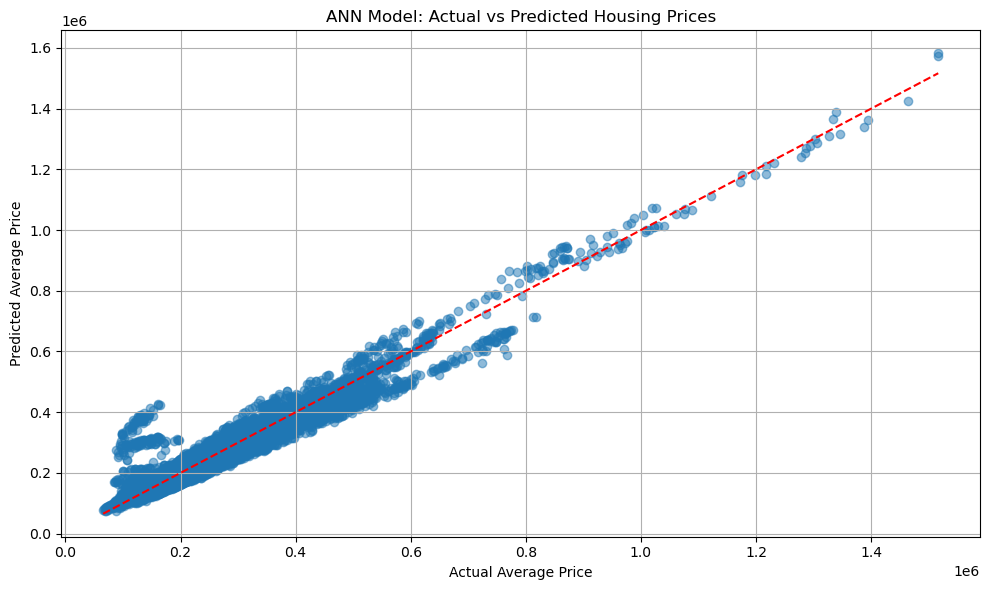

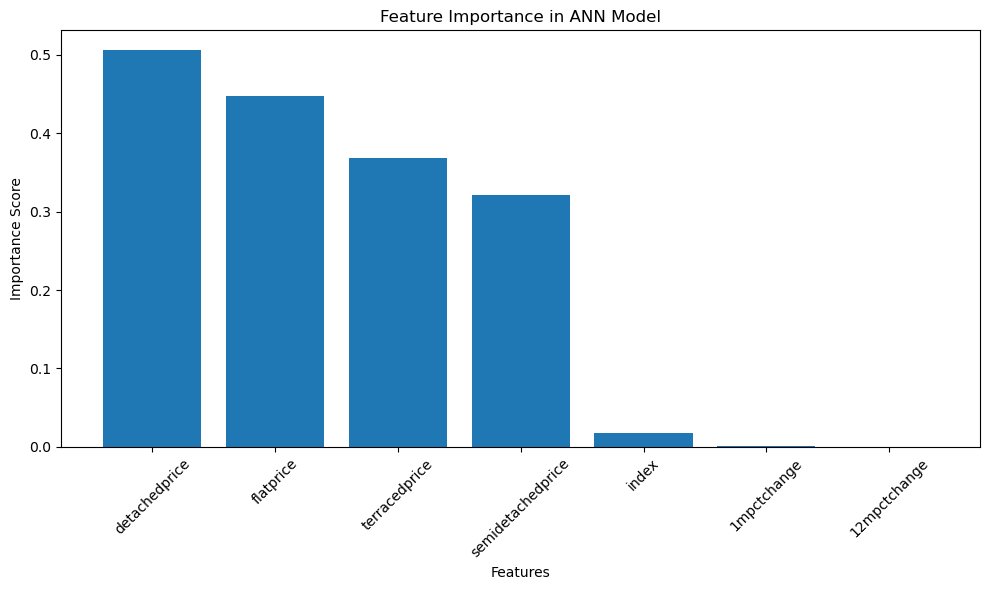

Feature Importance:
detachedprice: 0.5061
flatprice: 0.4470
terracedprice: 0.3685
semidetachedprice: 0.3212
index: 0.0174
1mpctchange: 0.0009
12mpctchange: 0.0004


In [133]:


# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

# Select relevant numerical features for our model
numerical_features = ['detachedprice', 'semidetachedprice', 'terracedprice', 'flatprice', 
                      'index', '1mpctchange', '12mpctchange']

# Create a copy of the dataframe with selected features
model_df = df[['date', 'regionname', 'averageprice'] + numerical_features].copy()

# Convert columns to numeric, coercing errors
for col in numerical_features + ['averageprice']:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Drop rows with missing values for our chosen columns
model_df = model_df.dropna(subset=['averageprice'] + numerical_features)

# Split features and target
X = model_df[numerical_features].values
y = model_df['averageprice'].values

# Split to train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train MLP Regressor (Artificial Neural Network)
print("Training Artificial Neural Network...")
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),  # Three hidden layers with 64, 32, and 16 neurons
    activation='relu',                # ReLU activation function
    solver='adam',                    # Adam optimizer
    alpha=0.0001,                     # L2 regularization term
    batch_size='auto',                # Batch size for gradient descent
    learning_rate='adaptive',         # Adaptive learning rate
    max_iter=500,                     # Maximum number of iterations
    early_stopping=True,              # Use early stopping
    validation_fraction=0.1,          # Fraction of training data for validation
    random_state=42                   # Random seed for reproducibility
)

mlp.fit(X_train_scaled, y_train)

# Predictions
y_pred = mlp.predict(X_test_scaled)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\
ANN Model Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.title('ANN Model: Actual vs Predicted Housing Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate feature importance using permutation importance
from sklearn.inspection import permutation_importance

result = permutation_importance(
    mlp, X_test_scaled, y_test, 
    n_repeats=10, 
    random_state=42
)

# Get importance scores
importance = result.importances_mean
feature_names = numerical_features

# Sort features by importance
indices = np.argsort(importance)[::-1]
sorted_feature_names = [feature_names[i] for i in indices]
sorted_importance = importance[indices]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importance)), sorted_importance)
plt.xticks(range(len(sorted_importance)), sorted_feature_names, rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importance in ANN Model')
plt.tight_layout()
plt.show()

# Print feature importance
print("\
Feature Importance:")
for i, feature in enumerate(sorted_feature_names):
    print(f"{feature}: {sorted_importance[i]:.4f}")

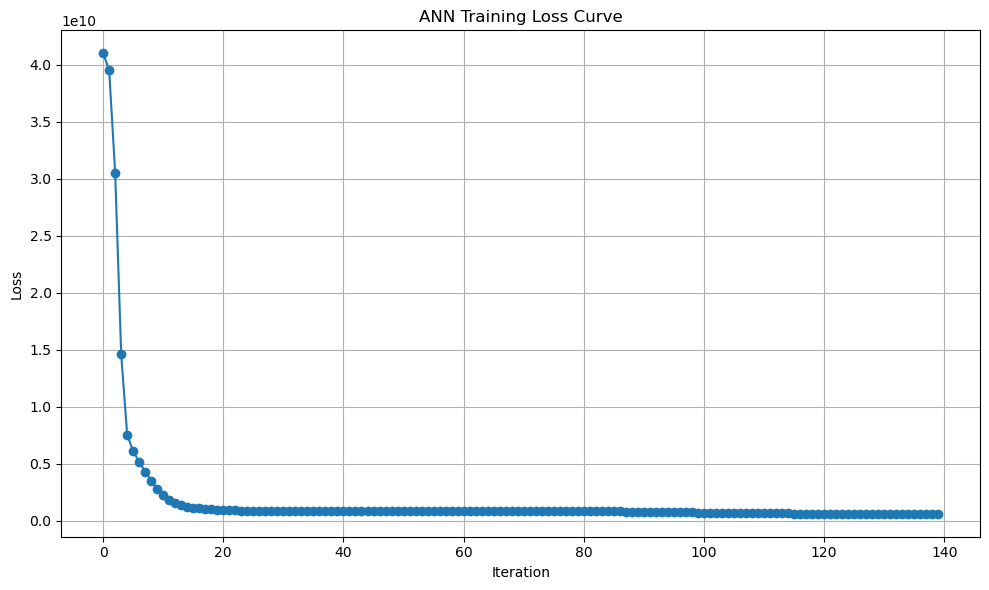

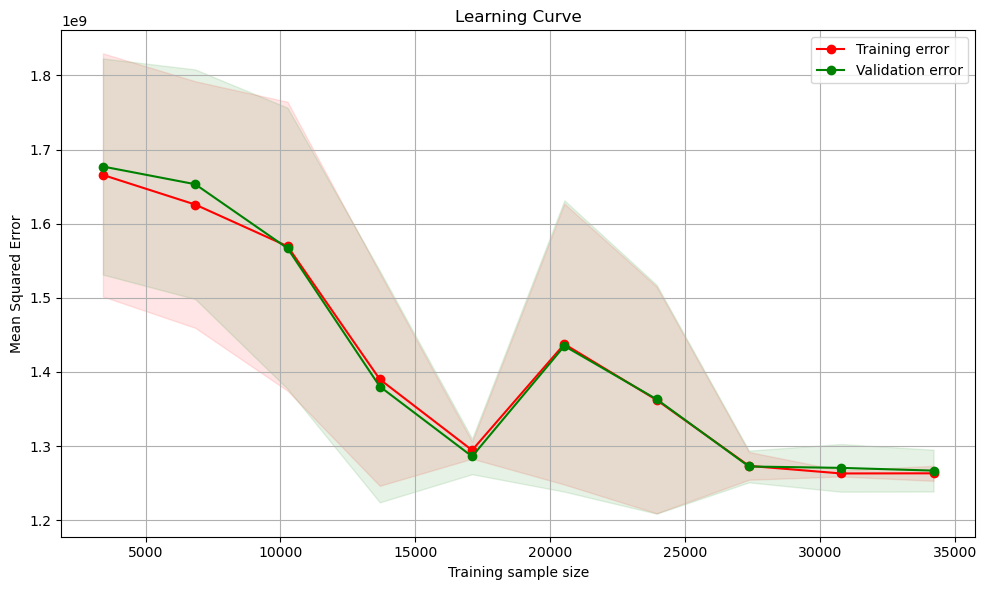

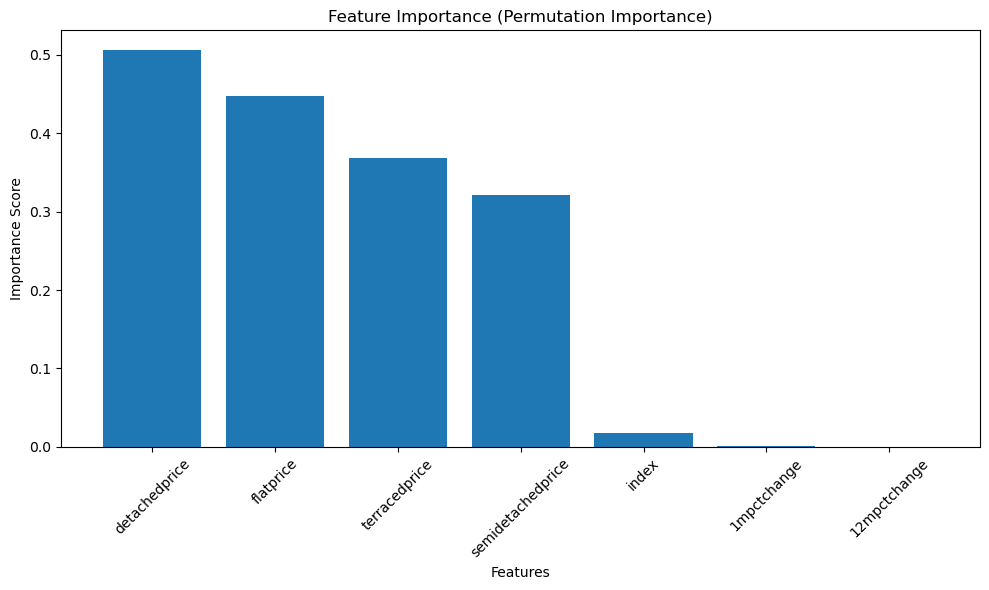

Plotted learning curve, loss curve, and feature importance.


In [137]:


# Plot the loss curve from MLPRegressor training
plt.figure(figsize=(10,6))
plt.plot(mlp.loss_curve_, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('ANN Training Loss Curve')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Learning Curve using learning_curve utility
train_sizes, train_scores, valid_scores = learning_curve(mlp, X_train_scaled, y_train,
                                                          train_sizes=np.linspace(0.1, 1.0, 10),
                                                          cv=5, scoring='neg_mean_squared_error',
                                                          random_state=42, n_jobs=-1)

# Calculate mean and std on scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
valid_scores_mean = -np.mean(valid_scores, axis=1)
valid_scores_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training error')
plt.plot(train_sizes, valid_scores_mean, 'o-', color='g', label='Validation error')
plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes,
                 valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.1, color='g')
plt.xlabel('Training sample size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance already computed using permutation_importance
# Plot feature importance again for clarity
result = permutation_importance(mlp, X_test_scaled, y_test, n_repeats=10, random_state=42)
importance = result.importances_mean
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importance)), importance[indices], align='center')
plt.xticks(range(len(importance)), [numerical_features[i] for i in indices], rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importance (Permutation Importance)')
plt.tight_layout()
plt.show()

print("Plotted learning curve, loss curve, and feature importance.")